# Install Dependencies

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer,load_iris
import aaia
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_score, recall_score

# Occupancy data loader

In [8]:
def load_occupancy_data():

    df_train = pd.read_csv('./data/occupancy_detection_train.csv')
    df_test = pd.read_csv('./data/occupancy_detection_test.csv')

    X_train = df_train.drop(columns=['id', 'date', 'Occupancy']).values
    y_train = df_train['Occupancy'].values

    X_test = df_test.drop(columns=['id', 'date', 'Occupancy']).values
    y_test = df_test['Occupancy'].values

    scaler = MinMaxScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    return X_train_scaled, y_train, X_test_scaled, y_test


# Cancer data loader

In [9]:
def load_cancer_data():
    data_bc = load_breast_cancer()
    X = data_bc.data
    y = data_bc.target

    scaler = MinMaxScaler()

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )

    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    return X_train_scaled, y_train, X_test_scaled, y_test


# Iris data loader

In [10]:
def load_iris_data():
    iris = load_iris()
    X = iris.data
    y = iris.target

    # train/test split: 30 per class train, 20 per class test
    train_idx, test_idx = [], []
    for cls in range(3):
        idx = np.where(y == cls)[0]
        train_idx.extend(idx[:30])
        test_idx.extend(idx[30:50])

    X_train, y_train = X[train_idx], y[train_idx]
    X_test, y_test = X[test_idx], y[test_idx]

    return X_train, y_train, X_test, y_test

# Load Data

In [11]:
datasets = {
    "Breast Cancer": load_cancer_data(),
    "Occupancy": load_occupancy_data(),
    "Iris": load_iris_data()
}

# Find best solution

In [12]:

results = {}

for name, (X_train, y_train, X_test, y_test) in datasets.items():
    print(f"Running for: {name}...")
    accuracies = []
    
    for i in range(10):
        best_sol = aaia.find_solution(X_train, max_iterations=1000, population_size=100)
        labels, _, _, _ = aaia.classify(X_train, y_train, X_test, best_sol)
        acc = accuracy_score(y_test, labels)
        accuracies.append(acc)
        print(f"  Iteration {i+1}/10: {acc:.4f}")
        
    results[name] = accuracies

Running for: Breast Cancer...
  Iteration 1/10: 0.6199
  Iteration 2/10: 0.8012
  Iteration 3/10: 0.7544
  Iteration 4/10: 0.7018
  Iteration 5/10: 0.7661
  Iteration 6/10: 0.8129
  Iteration 7/10: 0.8421
  Iteration 8/10: 0.6901
  Iteration 9/10: 0.8012
  Iteration 10/10: 0.6608
Running for: Occupancy...
  Iteration 1/10: 0.8338
  Iteration 2/10: 0.7396
  Iteration 3/10: 0.7047
  Iteration 4/10: 0.6488
  Iteration 5/10: 0.7268
  Iteration 6/10: 0.7039
  Iteration 7/10: 0.7719
  Iteration 8/10: 0.6555
  Iteration 9/10: 0.7069
  Iteration 10/10: 0.3062
Running for: Iris...
  Iteration 1/10: 0.5500
  Iteration 2/10: 0.7000
  Iteration 3/10: 0.6667
  Iteration 4/10: 0.7833
  Iteration 5/10: 0.7167
  Iteration 6/10: 0.8000
  Iteration 7/10: 0.6000
  Iteration 8/10: 0.6000
  Iteration 9/10: 0.6667
  Iteration 10/10: 0.6500


# Visualize

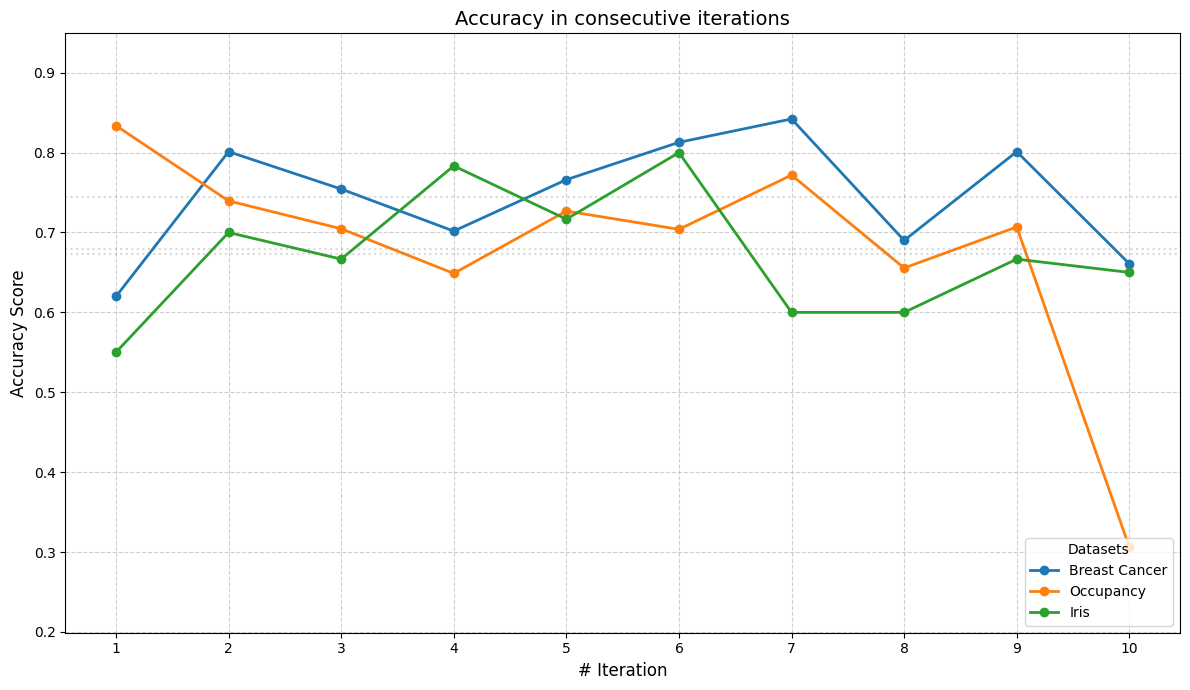

In [17]:
all_values = [acc for accs in results.values() for acc in accs]
y_min = min(all_values)
y_max = max(all_values)

margin = (y_max - y_min) * 0.2
if margin == 0: margin = 0.01

plt.figure(figsize=(12, 7))

for dataset_name, accuracies in results.items():
    iterations = np.arange(1, len(accuracies) + 1)
    plt.plot(iterations, accuracies, marker='o', linestyle='-', linewidth=2, label=dataset_name)

plt.title("Accuracy in consecutive iterations", fontsize=14)
plt.xlabel("# Iteration", fontsize=12)
plt.ylabel("Accuracy Score", fontsize=12)
plt.xticks(np.arange(1, 11)) 
plt.ylim(y_min - margin, y_max + margin)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title="Datasets", loc='lower right')

for dataset_name, accuracies in results.items():
    mean_acc = np.mean(accuracies)
    plt.axhline(mean_acc, color='gray', linestyle=':', alpha=0.3)

plt.tight_layout()
plt.show()

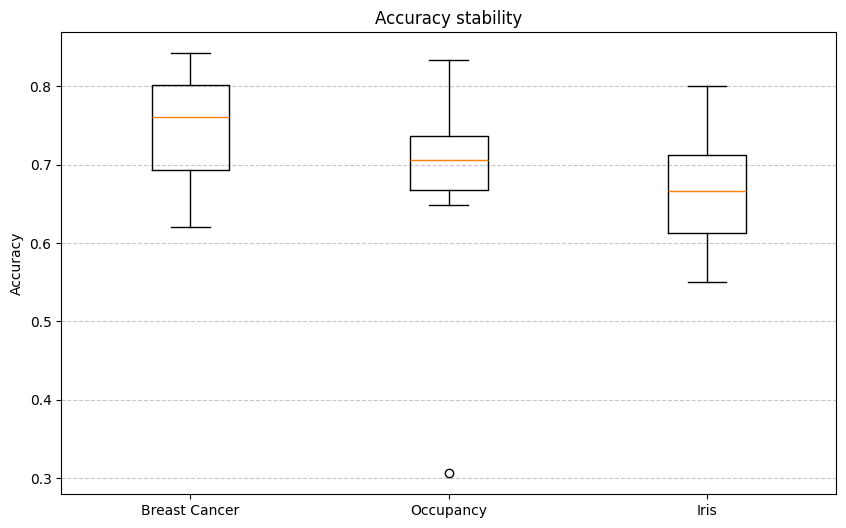

In [20]:
plt.figure(figsize=(10, 6))
plt.boxplot(results.values(), tick_labels=results.keys())
plt.title("Accuracy stability")
plt.ylabel("Accuracy")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()